In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-build graph. In this case the WECC example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [9]:
graph = good.graph.graph_from_json('Examples/WEC.json')

graph.nodes

NodeView(('WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE'))

Let's make this sepcific to California by making a subgraph

In [10]:
nodes = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID' , 'WECC_SCE']
graph = good.graph.subgraph(graph, nodes)
graph.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

First we will consider the current grid with no capacity expanison and no load shifting.

We will also not apply RPS constraints

In [51]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

nodes = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID' , 'WECC_SCE']
graph = good.graph.subgraph(graph, nodes)

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_capacity'] = 0

        if asset['_class'] == 'Store':

            asset['capex_capacity'] = np.inf
            asset['capex_cost'] = 1e3


In [53]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 1),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.07541203498840332
Variables Built: 0.02739548683166504
Constraints Built: 0.4869685173034668
Objective Built: 0.021591901779174805


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 17248, continuous_variables = 6628, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 6628), overall = Bunch(binary_variables = 0, constraints = 17248, continuous_variables = 6628, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 6628), warning = Bunch(unassociated_disjuncts = 0))

In [54]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 0.44547533988952637
Results Collected: 0.2206275463104248


In [56]:
import pyomo.environ as pe

pe.value(network.model.objective)

9306553.18451203

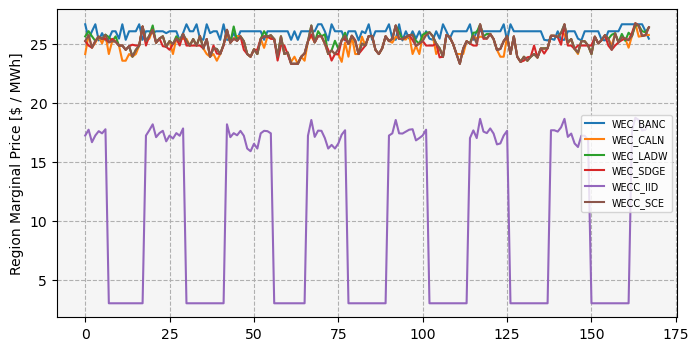

In [14]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

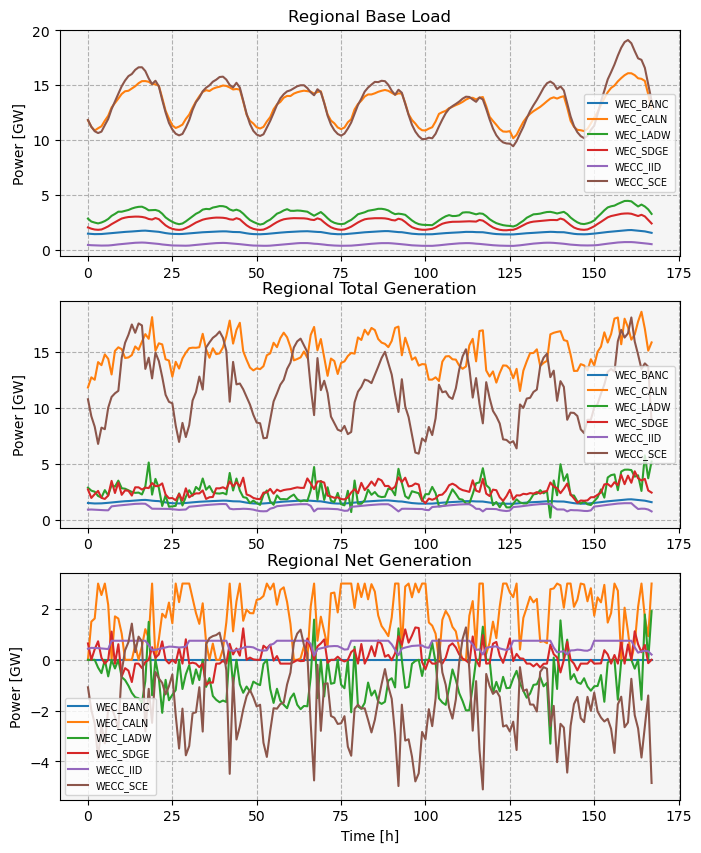

In [15]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

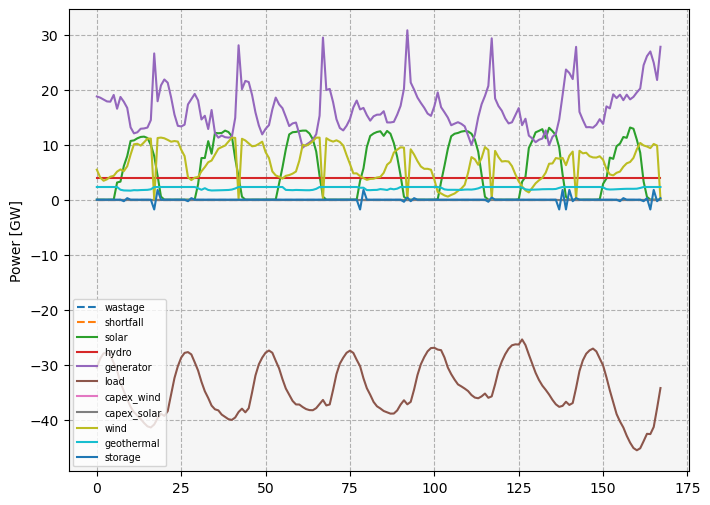

In [16]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

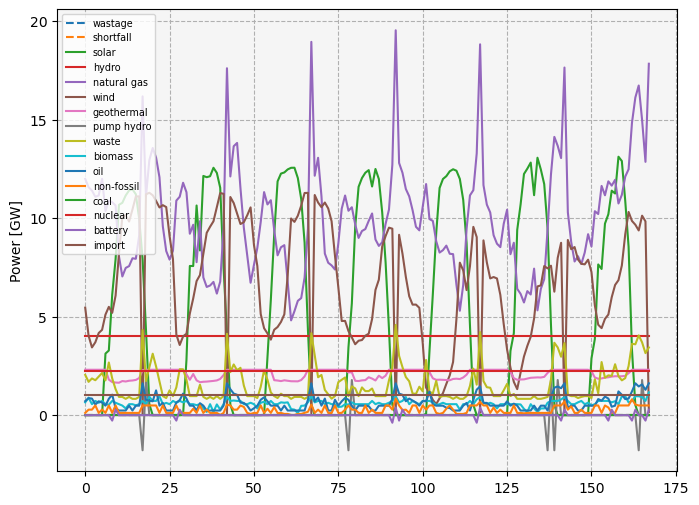

In [17]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

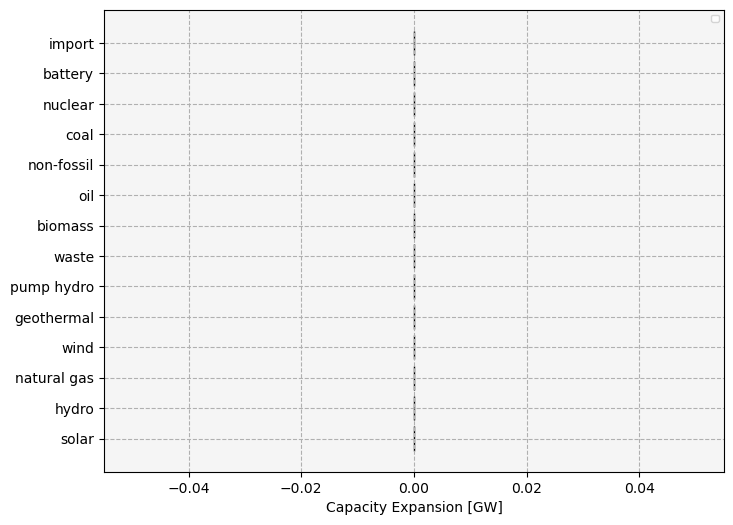

In [18]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Next we will consider the current grid with allowed capacity expanison and no load shifting.

In [286]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

nodes = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID' , 'WECC_SCE']
graph = good.graph.subgraph(graph, nodes)

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_cost'] /= (52 * 5)

        if asset['_class'] == 'Store':

            asset['capex_capacity'] = np.inf
            asset['capex_cost'] = 1e-3 / (52 * 5) * 1e-10
            # asset['production_rate'] = .25
            # asset['consumption_rate'] = .25

In [287]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = [])

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.21336817741394043
Variables Built: 0.16093754768371582
Constraints Built: 2.070460081100464
Objective Built: 0.445556640625


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 120640, continuous_variables = 46538, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 46538), overall = Bunch(binary_variables = 0, constraints = 120640, continuous_variables = 46538, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 46538), warning = Bunch(unassociated_disjuncts = 0))

In [288]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 14.33936357498169
Results Collected: 1.6222426891326904


In [289]:
import pyomo.environ as pe

pe.value(network.model.objective)

25224667.95642802

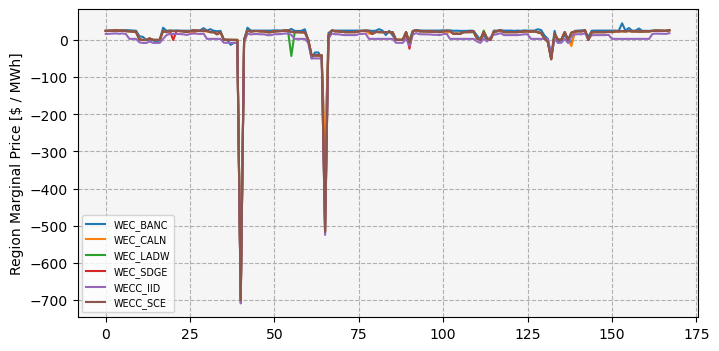

In [290]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

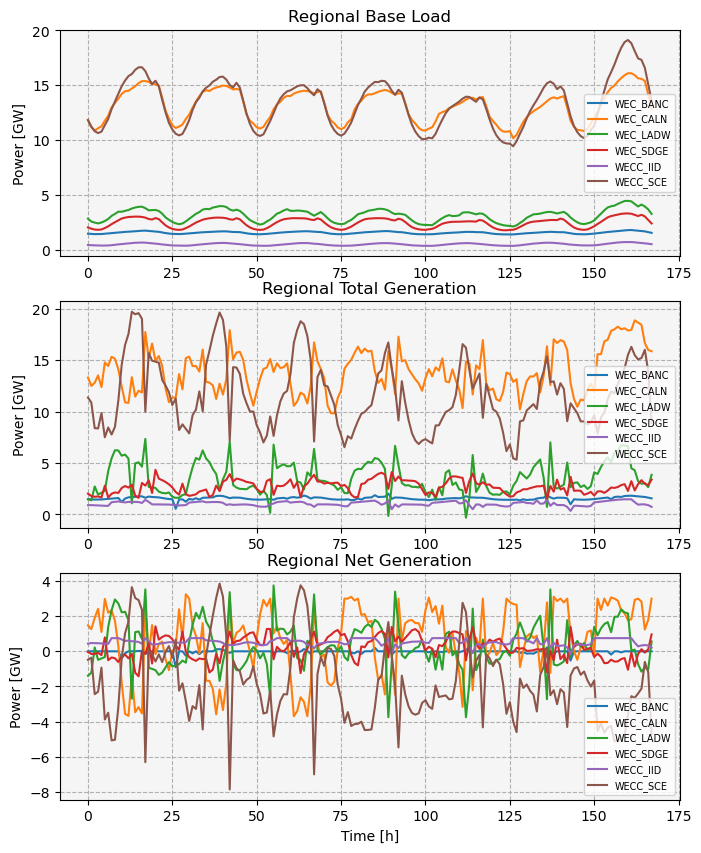

In [291]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

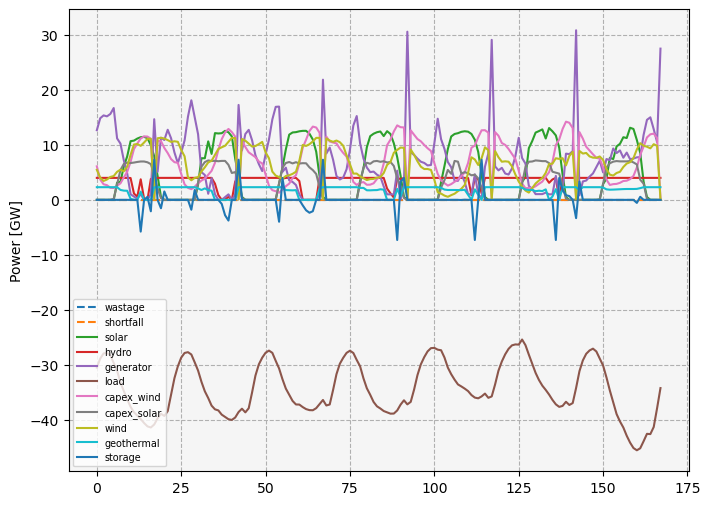

In [292]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

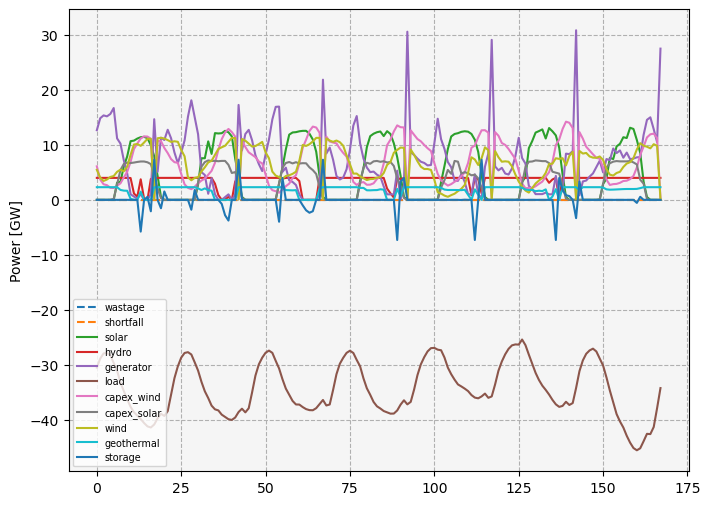

In [293]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

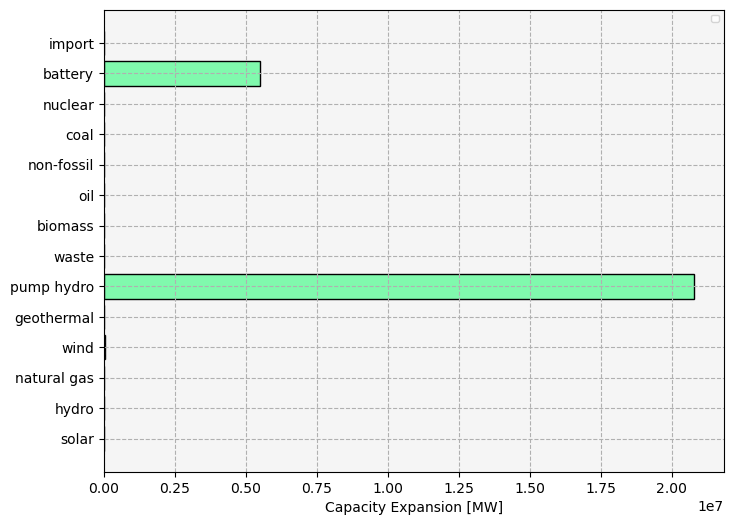

In [294]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [MW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Finally we will consider the current grid with allowed capacity expanison and allowed load shifting.

In [260]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

nodes = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID' , 'WECC_SCE']
graph = good.graph.subgraph(graph, nodes)

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_cost'] /= (52 * 5)

        if asset['type'] == 'load':

            asset['shift_portion'] = .1
            asset['capex_cost'] /= (52 * 5)


        if asset['_class'] == 'Store':

            asset['capex_capacity'] = np.inf
            asset['capex_cost'] = 1e-3 / (52 * 5)
            asset['production_rate'] = .25
            asset['consumption_rate'] = .25

In [261]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.2213444709777832
Variables Built: 0.17767596244812012
Constraints Built: 3.012678861618042
Objective Built: 0.13586735725402832


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 121655, continuous_variables = 47546, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 47546), overall = Bunch(binary_variables = 0, constraints = 121655, continuous_variables = 47546, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 47546), warning = Bunch(unassociated_disjuncts = 0))

In [262]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 3.308213472366333
Results Collected: 1.62723708152771


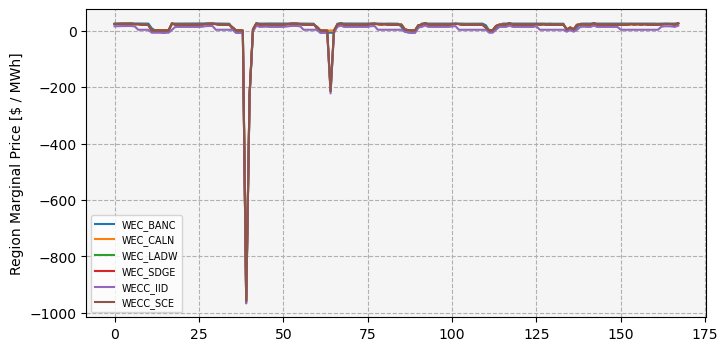

In [263]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

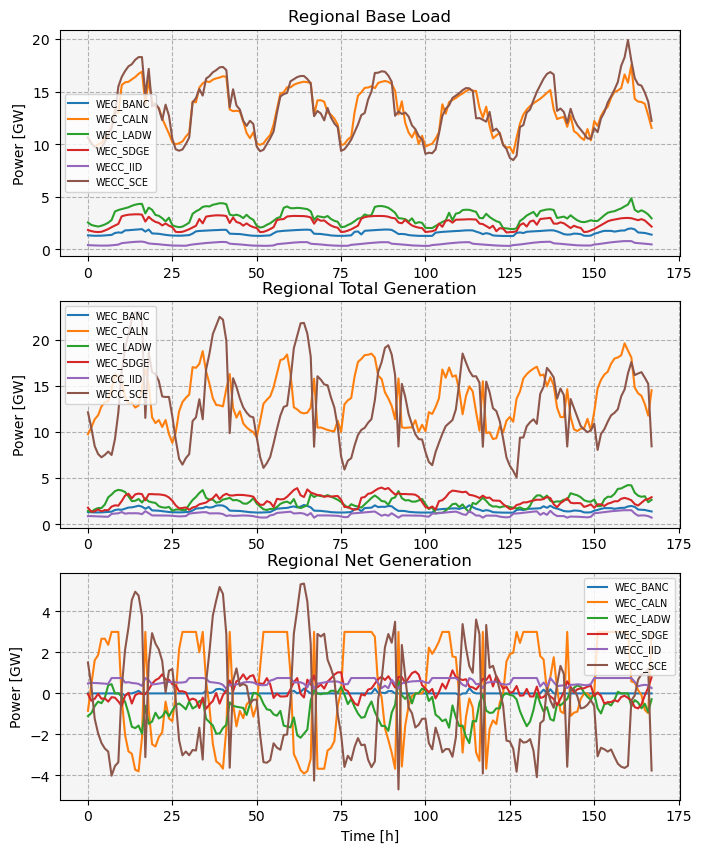

In [264]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

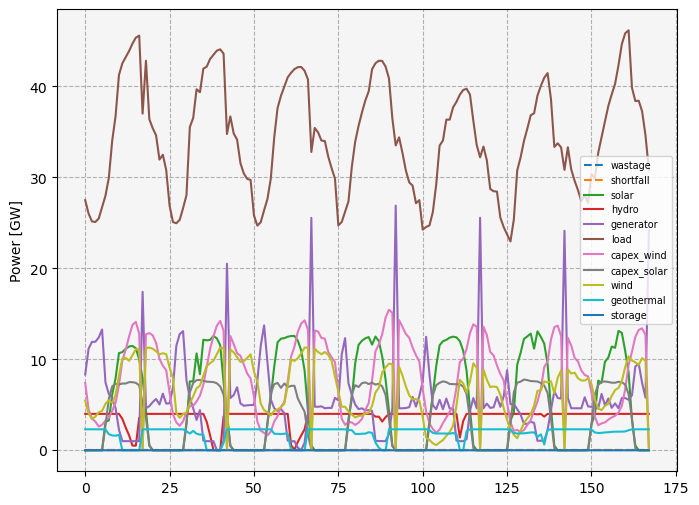

In [265]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

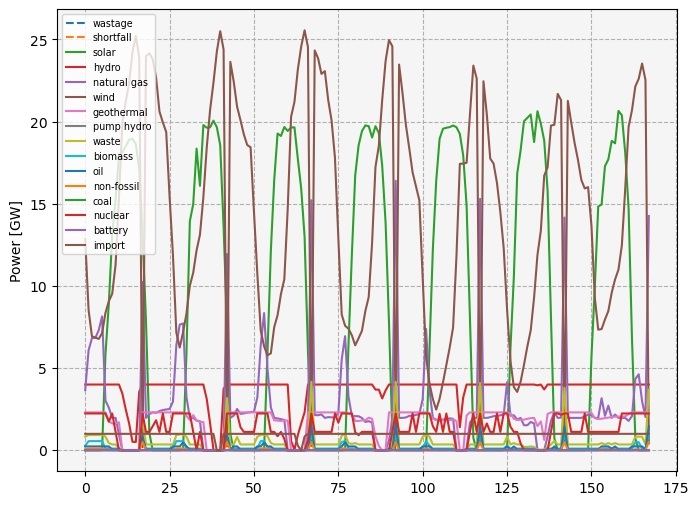

In [266]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

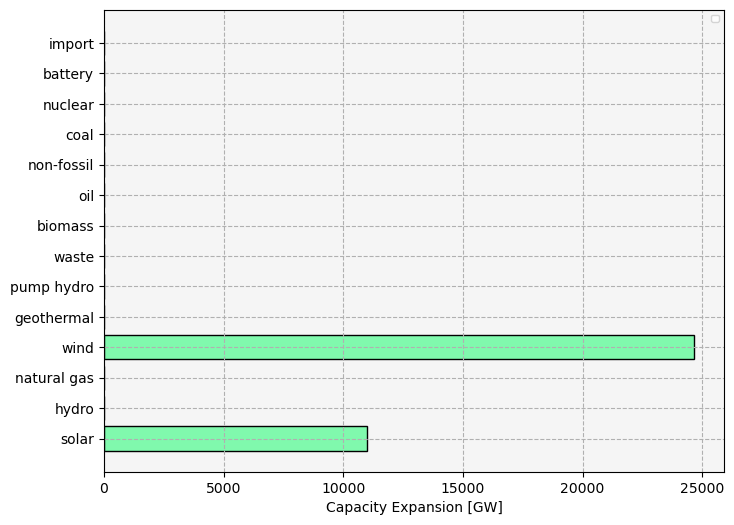

In [267]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)